In [1]:
import sys
sys.path.append("C:\\users\\cdfri\\dev\\physics-5700\\data\\2slit\\PMT_data\\")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [3]:
df_POS2 = pd.read_csv("C:/users/cdfri/dev/physics-5700/data/2slit/PMT_data/bulb_single_pos2.csv")
df_POS3 = pd.read_csv("C:/users/cdfri/dev/physics-5700/data/2slit/PMT_data/bulb_doubleslit.csv")
df_POS4 = pd.read_csv("C:/users/cdfri/dev/physics-5700/data/2slit/PMT_data/bulb_single_pos4.csv")

x_POS2, y_POS2, err_POS2 = df_POS2.slit_pos, df_POS2.count_rate_1s, df_POS2.error_1s
x_POS3, y_POS3, err_POS3 = df_POS3.slit_pos, df_POS3.count_rate_1s, df_POS3.error_1s
x_POS4, y_POS4, err_POS4 = df_POS4.slit_pos, df_POS4.count_rate_1s, df_POS4.error_1s

In [55]:
def I_single(x, A, x0, I0, y0):
    return I0 * (np.sin(A * (x - x0)) / (A * (x - x0)))**2. + y0

def dI_single_dx(x, A, I0, x0):
    X = x - x0
    numer = -2.0 * np.sin(A * X) * (np.sin(A * X) + (A * X) * np.cos(A * X))
    denom = A**2.0 + X**3.0
    return I0 * numer / denom

def I_double(x, B, A, I0, x0, y0):
    return I0 * ((np.sin(A * (x - x0)))**2. / (A * (x - x0))**2.) * (np.cos(B * (x - x0)))**2. + y0

def dI_double_dx(x, B, A, I0, x0):
    X = x - x0
    term1 = -8.0 * np.sin(A*X) * np.cos(B*X) * ((B * X)* np.sin(A*X) * np.sin(B*X))
    term2 = np.sin(A*X) + (A*x0 - A*x) * np.cos(A*X) * np.cos(B*X)
    denom = A**2.0 + X**3.0
    return I0 * (term1 + term2) / denom

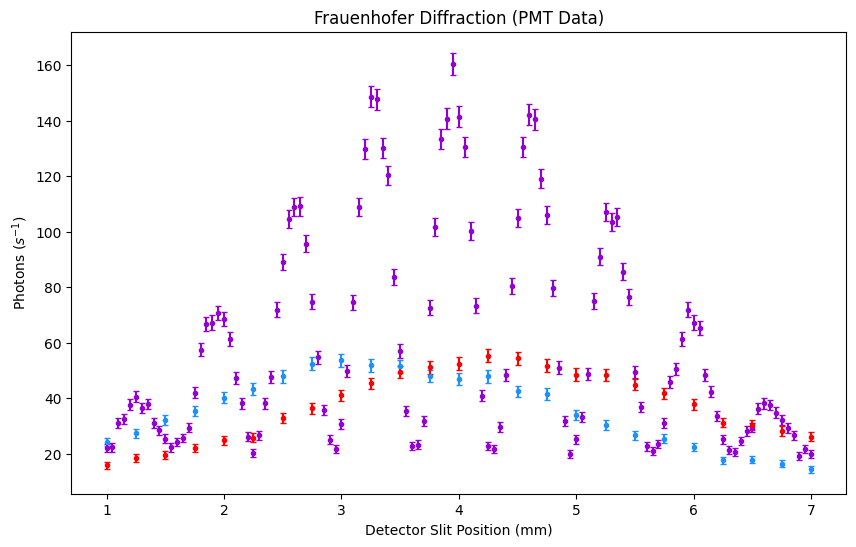

In [56]:
fig, ax = plt.subplots(figsize=(10,6))

plt.errorbar(x_POS2, y_POS2, yerr=err_POS2, c='dodgerblue', capsize=2, fmt='.')
plt.errorbar(x_POS3, y_POS3, yerr=err_POS3, c='darkviolet', capsize=2, fmt='.')
plt.errorbar(x_POS4, y_POS4, yerr=err_POS4, c='red', capsize=2, fmt='.')
ax.set_title("Frauenhofer Diffraction (PMT Data)")
ax.set_xlabel("Detector Slit Position (mm)")
ax.set_ylabel("Photons ($s^{-1}$)")

plt.show()

In [57]:
# FIT SINGLE SLIT CURVES
popt_POS2, pcov_POS2 = curve_fit(I_single, x_POS2, y_POS2, bounds=([0.0, 0.0, 0.0, 0.0], [np.inf,np.inf,np.inf, np.inf]), p0=[0.7,50,3.0, 13.4])
popt_POS4, pcov_POS4 = curve_fit(I_single, x_POS4, y_POS4, bounds=([0.0, 0.0, 0.0, 0.0], [np.inf,np.inf,np.inf, np.inf]), p0=[0.7,50,4.0, 13.4])

fit_err_POS2 = np.sqrt(np.diag(pcov_POS2))
fit_err_POS4 = np.sqrt(np.diag(pcov_POS4))

In [102]:
# FIT POS2 RESULTS
print("POS2:")
print("A:", popt_POS2[0], '+-', fit_err_POS2[0])
print("I0:", popt_POS2[1], '+-', fit_err_POS2[1])
print("x0:", popt_POS2[2], '+-', fit_err_POS2[2])
print(popt_POS2[3])
# FIT POS4 RESULTS
print("POS4:")
print("A:", popt_POS4[0], '+-', fit_err_POS4[0])
print("I0:", popt_POS4[1], '+-', fit_err_POS4[1])
print("x0:", popt_POS4[2], '+-', fit_err_POS4[2])
print(popt_POS4[3])

POS2:
A: 38.777887481870216 +- 3197231.5850795656
I0: 49.36375598601882 +- 3730930.296368764
x0: 2.388385458884316 +- 22614412.80759812
35.61599964058933
POS4:
A: 0.7874865462079685 +- 0.03253108189946813
I0: 4.410642480680241 +- 0.024433338069332886
x0: 38.03177560054198 +- 1.422280310514681
15.7665514684505


In [105]:
A = np.mean([popt_POS2[0], popt_POS4[0]])
A_err = np.mean([fit_err_POS2[0], fit_err_POS4[0]])
wl, wl_err = 546e-6, 5e-6 # mm
D, D_err = 496, 0.5 # mm

In [106]:
a = A * wl * D / np.pi
print(a)

1.7053350822781592


In [107]:
# FROM LASER DATA, PREDICTIONS OF a AND b
a = 0.071 # mm
b = 0.410 # mm

A_fit = np.pi * a / (wl * D)
B_fit = np.pi * b / (wl * D)

$A = \frac{\pi a}{\lambda D}$

$B = \frac{\pi b}{\lambda D}$

In [108]:
print(A_fit, B_fit)

0.8236333097190538 4.756192351898761


In [109]:
B_offset = -0.15
dark_rate = 15.8

fit_x = np.arange(1.0, 7.0, 0.001)
fit_y_POS2 = I_single(fit_x, A_fit, 3.39, 37.4, dark_rate)
fit_y_POS3 = I_double(fit_x, B_fit, A_fit, 144.0, 3.95, dark_rate)
fit_y_POS4 = I_single(fit_x, A_fit, 4.39, 38.03, dark_rate)

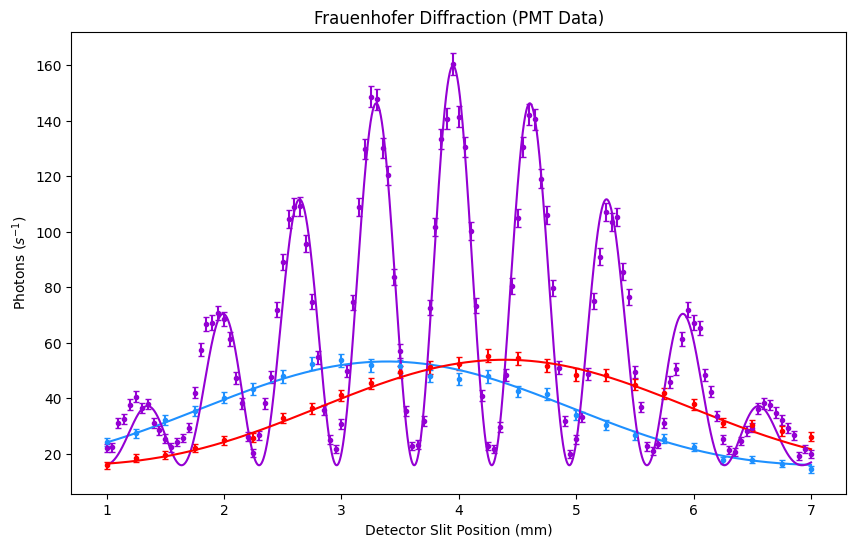

In [110]:
fig, ax = plt.subplots(figsize=(10,6))

plt.errorbar(x_POS2, y_POS2, yerr=err_POS2, c='dodgerblue', capsize=2, fmt='.')
plt.errorbar(x_POS3, y_POS3, yerr=err_POS3, c='darkviolet', capsize=2, fmt='.')
plt.errorbar(x_POS4, y_POS4, yerr=err_POS4, c='red', capsize=2, fmt='.')
ax.set_title("Frauenhofer Diffraction (PMT Data)")
ax.set_xlabel("Detector Slit Position (mm)")
ax.set_ylabel("Photons ($s^{-1}$)")

plt.plot(fit_x, fit_y_POS2, c='dodgerblue')
plt.plot(fit_x, fit_y_POS3, c='darkviolet')
plt.plot(fit_x, fit_y_POS4, c='red')

plt.show()